# Classification 

Linear regression is not a good algorithm for classfication problems, where an output can take only a handful of values.  

Some examples of (binary) classification are:
- Checking if an email is spam
- Checking if a transaction is fraudulent
- Checking if a tumor is malignant


### Implementation

In [40]:
import copy
import math
import numpy as np
import matplotlib.pyplot as plt
from utils.lab_utils_common_class import dlc, plot_data, plt_tumor_data, sigmoid, compute_cost_logistic
from utils.plt_one_addpt_onclick import plt_one_addpt_onclick
from utils.plt_logistic_loss import plt_logistic_cost, plt_two_logistic_loss_curves, plt_simple_example, soup_bowl, plt_logistic_squared_error
from utils.plt_quad_logistic import plt_quad_logistic, plt_prob

In [41]:
x_train = np.array([0., 1, 2, 3, 4, 5])
y_train = np.array([0,  0, 0, 1, 1, 1])
X_train2 = np.array([[0.5, 1.5], [1,1], [1.5, 0.5], [3, 0.5], [2, 2], [1, 2.5]])
y_train2 = np.array([0, 0, 0, 1, 1, 1])

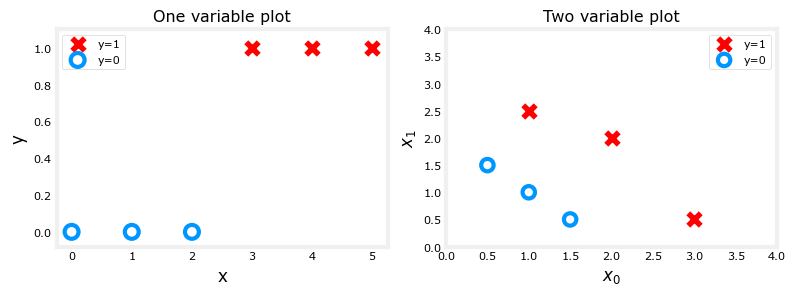

In [42]:
pos = y_train == 1
neg = y_train == 0

fig,ax = plt.subplots(1,2,figsize=(8,3))
#plot 1, single variable
ax[0].scatter(x_train[pos], y_train[pos], marker='x', s=80, c = 'red', label="y=1")
ax[0].scatter(x_train[neg], y_train[neg], marker='o', s=100, label="y=0", facecolors='none', 
              edgecolors=dlc["dlblue"],lw=3)

ax[0].set_ylim(-0.08,1.1)
ax[0].set_ylabel('y', fontsize=12)
ax[0].set_xlabel('x', fontsize=12)
ax[0].set_title('One variable plot')
ax[0].legend()

#plot 2, two variables
plot_data(X_train2, y_train2, ax[1])
ax[1].axis([0, 4, 0, 4])
ax[1].set_ylabel('$x_1$', fontsize=12)
ax[1].set_xlabel('$x_0$', fontsize=12)
ax[1].set_title('Two variable plot')
ax[1].legend()
plt.tight_layout()
plt.show()

### Logistic regression 

Logistic regression is used to predict the probability of a binary outcome based on input variables. Logistic regression uses a **sigmoid** function (or logistic function) to transform a linear combination of inputs into an S-shaped curve.

$$
g(z) = \frac{1}{1+e^{-z}}, 0 \leq g(z) \leq 1
$$

> **Note**
> Logistic regression is used for classification, not regression!

![sigmoid_function](../img/sigmoid_function.png)

To build the logistic regression algorithm:

- First, we have $z = \vec{w} \cdot \vec{x} + b$
- By inserting the above formula into $g(z)$, we get: $g(\vec{w} \cdot \vec{x} + b) = \frac{1}{1 + e^{-(\vec{w} \cdot \vec{x} + b)}}$

This can be interpreted as the probability that the class or label $y$ is equal to 1: $g(\vec{w} \cdot \vec{x} + b) = P(y = 1 | \vec{x}, \vec{w}, b)$.

For example, if $x$ is the "tumor size" property, and $y$ the probability that this tumor is malignant (or non-malignant), then $f_{\vec{w}, b}(\vec{x}) = 0.7$ means that there is 70% chance that $y = 1$ (i.e. 70% chance of the tumor being malignant). 





### Decision Boundary

The decision boundary is the line that separates the region where the model predicts 0 from the region where it predicts 1.

![decision-boundary](../img/decision-boundary.png)

A common prediction rule with threshold 0.5 is:
- If $f(x) \geq 0.5$, predict $\hat{y} = 1$
- If $f(x) < 0.5$, predict $\hat{y} = 0$

For **g(z) ≥ 0.5 ⇔ z ≥ 0**, we have 1 when $wx + b ≥ 0$ and 0 when $wx + b < 0$. This inequality defines the **decision boundary**. Decision boundary can also be polynomial by using higher-order terms like $x_1, x_2, x_1^2, x_2^2, x_1^3, x_2^3, ...$


### Cost Function for Logistic Regression

> Squared error cost function is not an ideal cost function for linear regression.

Why does the squared error function $J(w, b) = \frac{1}{m} \sum_{i=1}^m \frac{1}{2} (f_{\vec{w}, b}(\vec{x}^i) - y^i)^2$ does not work for logistic regression? 

- for **linear regression**, the cost function is convex; gradient descent successfully converges at the global minimum
- for **logistic regression**, the cost function is a sigmoid function, hence not convex; gradient descent leads to many local minima

![sqe_logistic_reg](../img/sqe_logistic_reg.png)


We instead use a loss function for logistic regression, defined by:

$
L\left( f_{\vec{w},b}(\vec{x}^{(i)}), y^{(i)} \right) = 
\begin{cases} 
-\log\left( f_{\vec{w},b}(\vec{x}^{(i)}) \right) & \text{if } y^{(i)} = 1 \\[8pt]
-\log\left( 1 - f_{\vec{w},b}(\vec{x}^{(i)}) \right) & \text{if } y^{(i)} = 0 
\end{cases}
$

- $f_{{w},b}({x}^{(i)})$ is the model's prediction, while $y^{(i)}$ is the target value.
- $f_{{w},b}({x}^{(i)}) = g({w} \cdot {x}^{(i)}+b)$ where function $g$ is the sigmoid function.


Since $y^{(i)}$ can have only two values, 0 and 1, the loss function above can be rewritten to be easier to implement.

$$
loss(f_{{w},b}({x}^{(i)}), y^{(i)}) = (-y^{(i)} \log\left(f_{{w},b}\left( {x}^{(i)} \right) \right) - \left( 1 - y^{(i)}\right) \log \left( 1 - f_{{w},b}\left( {x}^{(i)} \right) \right)
$$
  

When $ y^{(i)} = 0$, the left-hand term is eliminated:

$$
\begin{align}
loss(f_{{w},b}({x}^{(i)}), 0) &= (-(0) \log\left(f_{{w},b}\left( {x}^{(i)} \right) \right) - \left( 1 - 0\right) \log \left( 1 - f_{{w},b}\left( {x}^{(i)} \right) \right) \\
&= -\log \left( 1 - f_{{w},b}\left( {x}^{(i)} \right) \right)
\end{align}
$$

and when $ y^{(i)} = 1$, the right-hand term is eliminated:
$$
\begin{align}
  loss(f_{{w},b}({x}^{(i)}), 1) &=  (-(1) \log\left(f_{{w},b}\left( {x}^{(i)} \right) \right) - \left( 1 - 1\right) \log \left( 1 - f_{{w},b}\left( {x}^{(i)} \right) \right)\\
  &=  -\log\left(f_{{w},b}\left( {x}^{(i)} \right) \right)
\end{align}
$$




![logistic_loss_func](../img/logistic_loss_func.png)

![logistic_loss_func](../img/logistic_loss_func2.png)

From the above loss function we get the cost function, defined as follow: 

$$
\begin{align*}
{J}(\vec{w}, b) &= -\frac{1}{m} \sum_{i=1}^{m} \left[ L\left( f_{\vec{w},b}(\vec{x}^{(i)}), y^{(i)} \right) \right] \\[10pt]
&= -\frac{1}{m} \sum_{i=1}^{m} \Big[ y^{(i)} \log \left( f_{\vec{w},b}(\vec{x}^{(i)}) \right) + (1 - y^{(i)}) \log \left(1 - f_{\vec{w},b}(\vec{x}^{(i)}) \right) \Big]
\end{align*}
$$

> **Definition Note** 
> - **Loss** is a measure of the difference of a single example to its target value 
> - **Cost** is a measure of the losses over the training set


### Logistic Regression & Loss Implementation

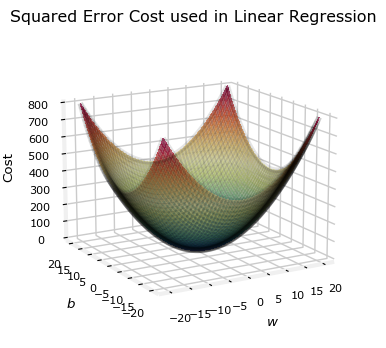

In [43]:
soup_bowl()

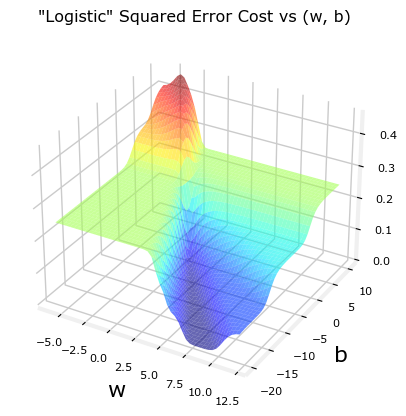

In [44]:
x_train = np.array([0., 1, 2, 3, 4, 5],dtype=np.longdouble)
y_train = np.array([0,  0, 0, 1, 1, 1],dtype=np.longdouble)
plt_simple_example(x_train, y_train)

plt.close('all')
plt_logistic_squared_error(x_train,y_train)
plt.show()

The surface above is not nearly as smooth as the 'soup bowl' from linear regression. Hence logistic regression requires a cost function more suitable to its non-linear nature, i.e. a loss function.

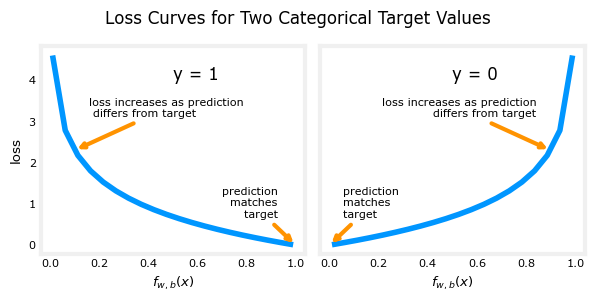

In [45]:
plt_two_logistic_loss_curves()

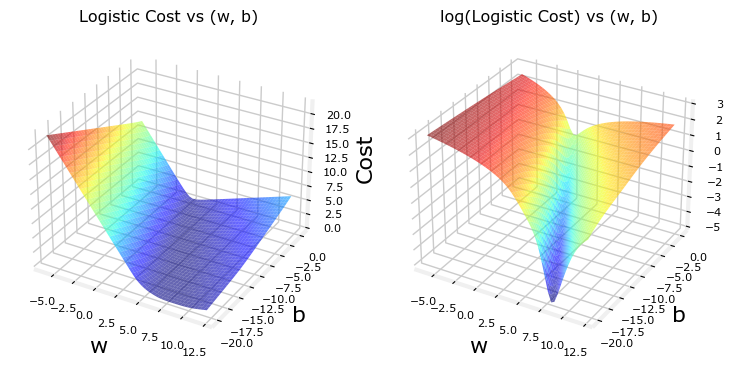

In [46]:
plt.close('all')
cst = plt_logistic_cost(x_train,y_train)

This curve is well suited to gradient descent: it does not have plateaus, local minima, or discontinuities.

But it is not a bowl as in the case of squared error. Both the cost and the log of the cost are plotted to illuminate the fact that the curve, when the cost is small, has a slope and continues to decline. 

### Gradient Descent for Logistic Regression

The algorithm used to minimize the cost function ${J}(\vec{w}, b) = -\frac{1}{m} \sum_{i=1}^{m} \Big[ y^{(i)} \log \left( f_{\vec{w},b}(\vec{x}^{(i)}) \right) + (1 - y^{(i)}) \log \left(1 - f_{\vec{w},b}(\vec{x}^{(i)}) \right) \Big]$ is gradient descent. 


$$
\text{repeat until convergence:} \quad
\left\{
\begin{aligned}
w_j &= w_j - \alpha \frac{\partial}{\partial w_j} J(\vec{w}, b) \\
    &= w_j - \alpha \frac{1}{m} 
       \sum_{i=1}^m (f_{w,b}(x^{(i)}) - y^{(i)})\, x_j^{(i)} \\[10pt]
b   &= b - \alpha \frac{\partial}{\partial b} J(\vec{w}, b) \\
    &= b - \alpha \frac{1}{m} 
       \sum_{i=1}^m (f_{w,b}(x^{(i)}) - y^{(i)})
\end{aligned}
\right.
$$

> The gradient descent rule is the same as the one used for linear regression, albeit the $f_{\vec{w},b}(x)$ function used is different. 

### Gradient Descent Implementation


In [47]:
X_train = np.array([[0.5, 1.5], [1,1], [1.5, 0.5], [3, 0.5], [2, 2], [1, 2.5]])
y_train = np.array([0, 0, 0, 1, 1, 1])

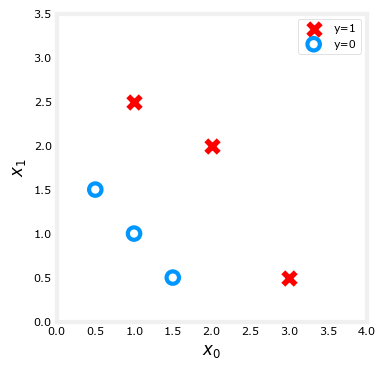

In [48]:
fig,ax = plt.subplots(1,1,figsize=(4,4))
plot_data(X_train, y_train, ax)

ax.axis([0, 4, 0, 3.5])
ax.set_ylabel('$x_1$', fontsize=12)
ax.set_xlabel('$x_0$', fontsize=12)
plt.show()

In [49]:
def compute_gradient_logistic(X, y, w, b): 
    """
    Computes the gradient for logistic regression 
 
    Args:
      X (ndarray (m,n): Data, m examples with n features
      y (ndarray (m,)): target values
      w (ndarray (n,)): model parameters  
      b (scalar)      : model parameter
    Returns
      dj_dw (ndarray (n,)): The gradient of the cost w.r.t. the parameters w. 
      dj_db (scalar)      : The gradient of the cost w.r.t. the parameter b. 
    """
    m,n = X.shape
    dj_dw = np.zeros((n,))                           #(n,)
    dj_db = 0.

    for i in range(m):
        f_wb_i = sigmoid(np.dot(X[i],w) + b)          #(n,)(n,)=scalar
        err_i  = f_wb_i  - y[i]                       #scalar
        for j in range(n):
            dj_dw[j] = dj_dw[j] + err_i * X[i,j]      #scalar
        dj_db = dj_db + err_i
    dj_dw = dj_dw/m                                   #(n,)
    dj_db = dj_db/m                                   #scalar
        
    return dj_db, dj_dw  

In [50]:
X_tmp = np.array([[0.5, 1.5], [1,1], [1.5, 0.5], [3, 0.5], [2, 2], [1, 2.5]])
y_tmp = np.array([0, 0, 0, 1, 1, 1])
w_tmp = np.array([2.,3.])
b_tmp = 1.
dj_db_tmp, dj_dw_tmp = compute_gradient_logistic(X_tmp, y_tmp, w_tmp, b_tmp)
print(f"dj_db: {dj_db_tmp}" )
print(f"dj_dw: {dj_dw_tmp.tolist()}" )

dj_db: 0.49861806546328574
dj_dw: [0.498333393278696, 0.49883942983996693]


In [51]:
def gradient_descent(X, y, w_in, b_in, alpha, num_iters): 
    """
    Performs batch gradient descent
    
    Args:
      X (ndarray (m,n)   : Data, m examples with n features
      y (ndarray (m,))   : target values
      w_in (ndarray (n,)): Initial values of model parameters  
      b_in (scalar)      : Initial values of model parameter
      alpha (float)      : Learning rate
      num_iters (scalar) : number of iterations to run gradient descent
      
    Returns:
      w (ndarray (n,))   : Updated values of parameters
      b (scalar)         : Updated value of parameter 
    """
    # An array to store cost J and w's at each iteration primarily for graphing later
    J_history = []
    w = copy.deepcopy(w_in)  #avoid modifying global w within function
    b = b_in
    
    for i in range(num_iters):
        # Calculate the gradient and update the parameters
        dj_db, dj_dw = compute_gradient_logistic(X, y, w, b)   

        # Update Parameters using w, b, alpha and gradient
        w = w - alpha * dj_dw               
        b = b - alpha * dj_db               
      
        # Save cost J at each iteration
        if i<100000:      # prevent resource exhaustion 
            J_history.append( compute_cost_logistic(X, y, w, b) )

        # Print cost every at intervals 10 times or as many iterations if < 10
        if i% math.ceil(num_iters / 10) == 0:
            print(f"Iteration {i:4d}: Cost {J_history[-1]}   ")
        
    return w, b, J_history         #return final w,b and J history for graphing


In [52]:
w_tmp  = np.zeros_like(X_train[0])
b_tmp  = 0.
alph = 0.1
iters = 10000

w_out, b_out, _ = gradient_descent(X_train, y_train, w_tmp, b_tmp, alph, iters) 
print(f"\nupdated parameters: w:{w_out}, b:{b_out}")

Iteration    0: Cost 0.684610468560574   
Iteration 1000: Cost 0.1590977666870457   
Iteration 2000: Cost 0.08460064176930078   
Iteration 3000: Cost 0.05705327279402531   
Iteration 4000: Cost 0.04290759421682   
Iteration 5000: Cost 0.03433847729884557   
Iteration 6000: Cost 0.02860379802212006   
Iteration 7000: Cost 0.02450156960879306   
Iteration 8000: Cost 0.02142370332569295   
Iteration 9000: Cost 0.019030137124109114   

updated parameters: w:[5.28123029 5.07815608], b:-14.222409982019837


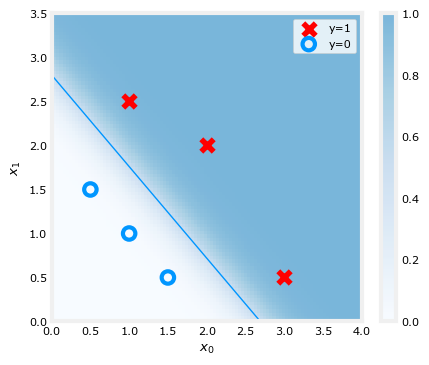

In [53]:
fig,ax = plt.subplots(1,1,figsize=(5,4))
# Plot the probability 
plt_prob(ax, w_out, b_out)

# Plot the original data
ax.set_ylabel(r'$x_1$')
ax.set_xlabel(r'$x_0$')   
ax.axis([0, 4, 0, 3.5])
plot_data(X_train,y_train,ax)

# Plot the decision boundary
x0 = -b_out/w_out[0]
x1 = -b_out/w_out[1]
ax.plot([0,x0],[x1,0], c=dlc["dlblue"], lw=1)
plt.show()

### Overfitting

Overfitting happens when an algorithm learns the training data **too well**, including its **fluctuations** (noise), so it fails to accurately predict unseen data. Unlike underfitting (which happens when the model is too simple), overfitting happens when too many features are taken into consideration (too complex). 

Below is a representation of underfitting, overfitting and a well-fit model for regression: 

![regression-fitting.png](../img/regression-fitting.png)

For classification, difference in fitting is shown below:

![classification-fitting.png](../img/classification-fitting.png)


Several strategies can be applied to overcome overfitting: 
- collect more data
- include/exclude specific features (in general, a good approach is to use only the most relevant ones) 
- regularization: assigns a penalty for complexity to the model

**Regularization** is a common solution to overfitting. It works by adding a penalty to the magnitude of model parameters, which prevents the model from fitting noise in the training data.


### Cost Function with Regularization 


High-degree models overfit because some parameters can become too large. By **forcing certain parameters to be small**, the model would become simpler and fitting just well.


In practice, all weights are penalized ($w_1, \dots, w_n$), but not the bias $b$. It works even with more than 100 features and without knowing the relative importance of each one. 

The regularized cost function becomes:

$$
J(\vec{w}, b) = \frac{1}{2m} \sum_{i=1}^m (f_{\vec{w}, b}(\vec{x}^{(i)}) - y^{(i)})^2 + \frac{\lambda}{2m} \sum_{j=1}^n w_j^2
$$

where:

- $m$ is the number of training examples
- $\lambda$ is the **regularization parameter**, controlling the degree of the penalty

If $\lambda = 0$, there is no regularization, and the model would overfit.
If $\lambda$ is very large, then parameters $w_j$ will almost be zero. The model would collapse to $f(x) ≈ b$ (flat line) and results in underfitting. 


A proper value for \lambda is one that suppresses unecessary noise while keeping the relative weights of $w_j$.  


### Regularized Linear Regression

Before adding regularization, gradient descent updated:

- each weight $w_j$ with $w_j := w_j - \alpha , \partial J / \partial w_j$
- bias $b := b - \alpha , \partial J / \partial b$

With regularization, we need to add the term $\frac{\lambda}{m}w_j$ for each weight. 

$$
\frac{\partial J}{\partial w_j}
=\frac{1}{m}\sum_{i=1}^m (f_{\vec{w},b}(\vec{x}^{(i)})-y^{(i)})x_j^{(i)} + \frac{\lambda}{m} w_j
$$

$$
\frac{\partial J}{\partial b}
=\frac{1}{m}\sum_{i=1}^m (f_{\vec{w},b}(\vec{x}^{(i)})-y^{(i)})
$$

From these, the gradient descent update becomes:

$$
\text{repeat until convergence:} \quad
\left\{
\begin{aligned}
w_j &= w_j - \alpha \left( \frac{1}{m} \sum_{i=1}^{m} \big(f_{\vec{w},b}(\vec{x}^{(i)}) - y^{(i)}\big) x_j^{(i)} + \frac{\lambda}{m} w_j \right), \quad j = 1, \dots, n\\[2mm]
b &= b - \alpha \left( \frac{1}{m} \sum_{i=1}^{m} \big(f_{\vec{w},b}(\vec{x}^{(i)}) - y^{(i)}\big) \right)
\end{aligned}
\right.
$$


### Regularized Logistic Regression

Regularization in logistic regression works just like in linear regression: it penalizes large weights to reduce overfitting, leading to simpler models. 

The cost function for logistic regression is the same as the one used for linear regression, although $f$ is different. 

$$
\underset{\vec{w},b}{\operatorname{minimize}} \quad
J(\vec{w},b) = -\frac{1}{m}\sum_{i=1}^m \left[ y^{(i)}\log\big(f_{\vec{w},b}(\vec{x}^{(i)})\big) + (1-y^{(i)})\log\big(1-f_{\vec{w},b}(\vec{x}^{(i)})\big) \right] + \frac{\lambda}{2m}\sum_{j=1}^n w_j^2
$$

**Gradient descent**

$$
\text{repeat until convergence:} \quad
\left\{
\begin{aligned}
w_j = w_j - \alpha \underbrace{\left[ \frac{1}{m} \sum_{i=1}^m \big(f_{\vec{w},b}(\vec{x}^{(i)})-y^{(i)}\big) \, x_j^{(i)} + \frac{\lambda}{m} w_j \right]}_{\text{same as linear regression!}} \quad j = 1,\dots,n \\[4mm]
b = b - \alpha \left[ \frac{1}{m} \sum_{i=1}^m \big(f_{\vec{w},b}(\vec{x}^{(i)})-y^{(i)}\big) \right]
\end{aligned}
\right.
$$